In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import sys
sys.path.append("..")
from scripts import rewire, indices

# average efficiency

In [3]:
f = open('../Output/Determ/rand_dist_nor.pckl', 'rb')
A_matrices = pickle.load(f)
f.close()

In [4]:
ave_eff = {}

In [5]:
for q in A_matrices.keys():
    ave_eff[q] = {}
    for k in A_matrices[q].keys():
        ave_eff[q][k] = {}
        for ind in A_matrices[q][k].keys():
            ave_eff[q][k][ind] = indices.average_efficiency(A_matrices[q][k][ind])

In [6]:
fname = '../Output/Determ/rand_dist_eff.pckl'
f = open(fname, 'wb')
pickle.dump(ave_eff, f)
f.close()

# Fig S3

In [9]:
f = open('../Output/Determ/rand_dist_eff.pckl', 'rb')
rand_dist_eff = pickle.load(f)
f.close()

f = open('../Output/Determ/rand_eff_stb.pckl', 'rb')
rand_eff = pickle.load(f)
f.close()

f = open('../Output/Determ/dist_eff_stb.pckl', 'rb')
dist_eff = pickle.load(f)
f.close()

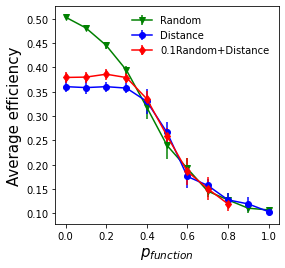

In [11]:
colorsPlot = [ 'orange', 'green','blue','red','cyan']
shapePoint = ['--s','-v','-o','-d','-h']
shapePointNoLine = ['s','v','o','d','h']
plt.rcParams['figure.figsize'] = [4, 4]

p_in = 0.5; K=10; step = 15000
r_list = list(map(lambda x: x/10,range(11))) #p_function

mu = []; sig = []; ind = 1
for r in r_list:
    p = round(1-r,1)
    cp_temp = np.zeros(K)
    for k in range(K):
        cp_temp[k] = np.sum(rand_eff[p_in][p][k][step])
    mu.append(np.mean(cp_temp))
    sig.append(np.std(cp_temp))
plt.errorbar(r_list,mu,sig,
             mfc=colorsPlot[ind], mec=colorsPlot[ind], 
             marker=shapePointNoLine[ind],
             color=colorsPlot[ind],
             label = 'Random')

mu = []; sig = []; ind = 2
for r in r_list:
    p = round(1-r,1)
    cp_temp = np.zeros(K)
    for k in range(K):
        cp_temp[k] = np.sum(dist_eff[p_in][p][k][step])
    mu.append(np.mean(cp_temp))
    sig.append(np.std(cp_temp))
plt.errorbar(r_list,mu,sig,
             mfc=colorsPlot[ind], mec=colorsPlot[ind], 
             marker=shapePointNoLine[ind],
             color=colorsPlot[ind],label = 'Distance')

r_list = list(map(lambda x: x/10,range(9)))
mu = []; sig = []; ind = 3
for r in r_list:
    q = round(1-0.1-r,1)
    cp_temp = np.zeros(K)
    for k in range(K):
        cp_temp[k] = np.sum(rand_dist_eff[q][k][step])
    mu.append(np.mean(cp_temp))
    sig.append(np.std(cp_temp))
plt.errorbar(r_list,mu,sig,
             mfc=colorsPlot[ind], mec=colorsPlot[ind], 
             marker=shapePointNoLine[ind],
             color=colorsPlot[ind],
             label = '0.1Random+Distance')

plt.ylabel('Average efficiency',fontsize=15)
plt.xlabel('$p_{function}$',fontsize=15)
plt.legend(frameon=False)
plt.savefig('../Output/figure/S3&4/3.eps',dpi=300, bbox_inches='tight')